## Notebook for Reproducible Model Training

This is the notebook version of the modeling performed for the Carnegie Mellon Sports Analytics Conference (CMSAC). 

This notebook comes after the user has successfully run the data engineering pipelines. Please refer to the `README.md`

In [32]:
# Installed Python packages
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import arviz as az
import xarray as xr

# Custom helper functions unique to this repo
from tempoctrl.visualize.summary_statistics import plot_histogram
from tempoctrl.investigate_utils import summarize_variables
from tempoctrl.model.transform import polars_enum_to_ordered_pandas
from tempoctrl.model.utils import (
    build_player_effects_table,
    discover_archetypes,
    summarize_archetype_overlap
)


## Descriptive Statistics

In [4]:
model_df = pl.read_parquet("../../data/analysis/model_data_vFINAL.parquet")

display(model_df["game_id"].unique().shape[0])
display(model_df["match_team_possession_id"].unique().shape[0])
display(model_df["match_team_player_possession_id"].unique().shape[0])

64

14357

59587

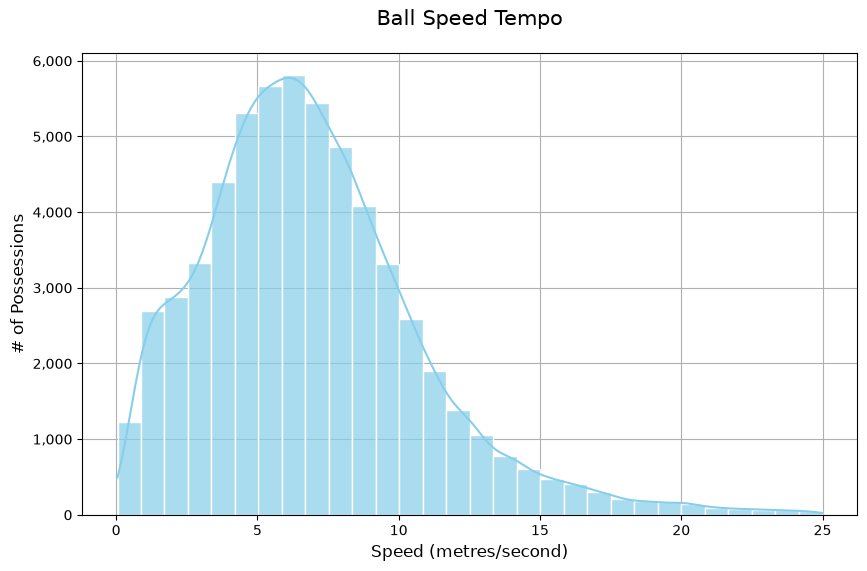

In [11]:
plot_histogram(
    dataframe=model_df,
    continuous_variable="ball_speed_tempo_player",
    title = "Ball Speed Tempo",
    title_fontsize = 15,
    x_label = "Speed (metres/second)",
    y_label = "# of Possessions"
)
plt.show()

In [13]:
cat = ('starting_pitch_third',
 'setpiecetype',
 'first_touch_ballheight',
 'first_touch_bodypart',
 'first_touch_defender_pressure_type',
 'defender_num_challenges',
 'game_period',
 'player_position_group',
 'started')

with pl.Config(tbl_rows = 33):
    display(summarize_variables(model_df.select(cat))["categorical"])

column_name,category,count,percentage,unique_category_count
str,str,u32,f64,u32
"""starting_pitch_third""","""Middle""",31623,53.070301,3
"""starting_pitch_third""","""Defensive""",16192,27.173712,3
"""starting_pitch_third""","""Attacking""",11772,19.755987,3
"""setpiecetype""","""Open Play""",59587,100.0,1
"""first_touch_ballheight""","""Ground""",44108,74.022857,2
"""first_touch_ballheight""","""Air""",15479,25.977143,2
"""first_touch_bodypart""","""Foot""",53936,90.516388,6
"""first_touch_bodypart""","""Head""",2585,4.338195,6
"""first_touch_bodypart""","""Torso/Other""",1618,2.715357,6


In [14]:
with pl.Config(tbl_rows = 13):
    display(summarize_variables(model_df)["continuous"])

column_name,min,median,mean,max,standard_deviation,variance,outside_mean_plus_minus_std_count
str,f64,f64,f64,f64,f64,f64,u32
"""game_id""",3812.0,3844.0,5595.225603,10517.0,2940.774652,8.6482e6,15712
"""player_possession_sequence_num…",1.0,4.0,5.505194,57.0,5.204432,27.086113,7587
"""elapsed_seconds_team_possessio…",0.0,7.874541,13.231817,171.604938,15.904043,252.938587,7697
"""ball_speed_tempo_player""",0.047321,6.469799,6.920315,24.982991,3.860031,14.899838,16954
"""total_ball_displacement""",0.01,16.168629,17.820126,127.758355,11.950309,142.809895,17801
"""elapsed_frames""",1.0,73.0,83.046101,721.0,52.756305,2783.227711,15104
"""event_number""",2.0,1101.0,1120.5448,3023.0,664.803688,441963.943731,23922
"""player_id""",1.0,4324.0,5498.271989,14040.0,4908.439034,2.4093e7,24654
"""team_id""",50.0,367.0,311.160673,386.0,124.391239,15473.180273,11173


#### Polars to Pandas

Convert data to pandas as the `bambi` package does not work with poalrs dataframes

In [ ]:
model_pd_df = polars_enum_to_ordered_pandas(model_df)
model_pd_df.describe()

categorical_cols = [
    "setpiecetype",
    "first_touch_ballheight",
    "first_touch_defender_pressure_type",
    "starting_pitch_third",
    "player_position_group",
    "game_period",
]

# Check if reference levels are kept intact (first => reference level)
for col in categorical_cols:
    print(
        col,
        model_pd_df[col].cat.categories.tolist(),
        model_pd_df[col].cat.ordered,
    )

setpiecetype ['Open Play', 'Dead Ball'] True
first_touch_ballheight ['Ground', 'Air'] True
first_touch_defender_pressure_type ['No Pressure', 'Pressured (inc. Attempted Pressure)'] True
starting_pitch_third ['Middle', 'Defensive', 'Attacking'] True
player_position_group ['Midfielder', 'Goalkeeper', 'Centre Back', 'Full Back', 'Winger', 'Forward'] True
game_period ['1', '2', 'AET'] True


# Bayesian Hierarchical Models



### Priors

In [19]:
# Mu model
mu_intercept_prior = bmb.Prior(
    "Normal",
    mu=np.log(7.0),
    sigma=0.4,
    auto_scale=False,
)

mu_common_prior = bmb.Prior(
    "Normal",
    mu=0.0,
    sigma=0.3,
    auto_scale=False,
)

mu_group_sd_prior = bmb.Prior(
    "HalfNormal",
    sigma=0.3,
    auto_scale=False,
)

mu_group_prior = bmb.Prior(
    "Normal",
    mu=0.0,
    sigma=mu_group_sd_prior,
    auto_scale=False,
)

# Shape model
alpha_intercept_prior = bmb.Prior(
    "Normal",
    mu=np.log(3.0),
    sigma=0.5,
    auto_scale=False,
)

alpha_common_prior = bmb.Prior(
    "Normal",
    mu=0.0,
    sigma=0.3,
    auto_scale=False,
)

alpha_group_sd_prior = bmb.Prior(
    "HalfNormal",
    sigma=0.3,
    auto_scale=False,
)

alpha_group_prior = bmb.Prior(
    "Normal",
    mu=0.0,
    sigma=alpha_group_sd_prior,
    auto_scale=False,
)

priors = {
    "mu": {
        "Intercept": mu_intercept_prior,
        "common": mu_common_prior,
        "group_specific": mu_group_prior,
    },
    "alpha": {
        "Intercept": alpha_intercept_prior,
        "group_specific": alpha_group_prior,
    },
}

### Model Formulation

In [20]:
tempo_formula = bmb.Formula(
    '''
    ball_speed_tempo_player ~ 1 
        + (1 | player_id)
        + (1 | opponent_id)
        + game_state_goal_diff
        + first_touch_ballheight
        + first_touch_defender_pressure_type
        + defender_num_challenges
        + starting_pitch_third
        + player_position_group
        + player_possession_sequence_log_z
        + game_period
    ''',
    '''alpha ~ 1
        + first_touch_defender_pressure_type
        + defender_num_challenges
        + starting_pitch_third
        + player_position_group
        + (1 | player_id)
    '''
)

model = bmb.Model(formula = tempo_formula,
                  data = model_pd_df,
                  family = "gamma",
                  link={
                        "mu" : "log",
                        "alpha" : "log"
                    },
                    priors=priors,
                  categorical=[
                        "player_id",
                        "opponent_id",
                        "first_touch_ballheight",
                        "first_touch_defender_pressure_type",
                        "starting_pitch_third",
                        "player_position_group",
                        "game_period",
                    ]
                )

print(model)

       Formula: 
    ball_speed_tempo_player ~ 1 
        + (1 | player_id)
        + (1 | opponent_id)
        + game_state_goal_diff
        + first_touch_ballheight
        + first_touch_defender_pressure_type
        + defender_num_challenges
        + starting_pitch_third
        + player_position_group
        + player_possession_sequence_log_z
        + game_period
    
                alpha ~ 1
        + first_touch_defender_pressure_type
        + defender_num_challenges
        + starting_pitch_third
        + player_position_group
        + (1 | player_id)
    
        Family: gamma
          Link: mu = log
                alpha = log
  Observations: 59587
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.9459, sigma: 0.4)
            game_state_goal_diff ~ Normal(mu: 0.0, sigma: 0.3)
            first_touch_ballheight ~ Normal(mu: 0.0, sigma: 0.3)
            first_touch_defender_pressure_type ~ Normal(mu: 0.0, sigma: 0.3)
  

### Run Posterior Draws

If you have already run this notebook end-to-end, there will be two `.nc` files in the `paper\results\` folder that can be loaded instead of running the draws from scratch. 

Skip to the "Load Posterior Draws" section if you want to use those files instead.

These runs took: 

- roughly ~17 minutes on a 2025 Macbook Air M4 Silicon Chip with 16 GB RAM and 512 GB SSD (running MacOS)
- roughly ~ minutes on a 2015 HP Spectre x360 with i7 Intel Core with 8 GB RAM and 256 GB SSD (running Linux Mint xFCE)

In [ ]:
gamma_idata = model.fit(
    draws=1000,
    tune=1500,
    chains = 4,
    cores = 4,
    target_accept=0.90,
    random_seed=42,
    log_likelihood = False
)

# Save results for easy loading downstream

gamma_idata.to_netcdf(
    "../../paper/results/tempo_gamma_posterior.nc",
    engine="h5netcdf",
)


### Load Posterior Draws

In [25]:
gamma_idata = xr.open_datatree(
    "../../paper/results/tempo_gamma_posterior.nc",
    engine="h5netcdf",
)

model_summary = az.summary(gamma_idata, 
                           ci_kind = "hdi", 
                           ci_prob=0.95)

In [30]:
model_summary[0:18]

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,1.9974,0.0088,2,2,3363,3091,1.00,0.00015,0.00011
game_state_goal_diff,0.00712,0.00209,0.003,0.011,5986,3204,1.00,2.7e-05,2e-05
first_touch_ballheight[Air],-0.0528,0.00588,-0.064,-0.042,8748,3323,1.00,6.3e-05,4.5e-05
first_touch_defender_pressure_type[Pressured (inc. Attempted Pressure)],0.1986,0.00599,0.19,0.21,8377,3199,1.00,6.6e-05,4.9e-05
defender_num_challenges[1],-0.3759,0.0103,-0.4,-0.36,8634,3002,1.00,0.00011,7.8e-05
defender_num_challenges[2+],-0.7579,0.0221,-0.8,-0.71,7696,2892,1.00,0.00025,0.00018
starting_pitch_third[Defensive],-0.0194,0.0057,-0.031,-0.0083,8546,3296,1.00,6.2e-05,4.4e-05
starting_pitch_third[Attacking],-0.1392,0.007,-0.15,-0.13,8597,3081,1.00,7.5e-05,5.2e-05
player_position_group[Goalkeeper],-0.0674,0.0186,-0.1,-0.031,5709,4006,1.00,0.00025,0.00017
player_position_group[Centre Back],0.0254,0.0098,0.0064,0.045,3615,3225,1.00,0.00016,0.00012


In [31]:
model_summary[20:]

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha_defender_num_challenges[1],-0.5262,0.0191,-0.56,-0.49,7751,3271,1.00,0.00022,0.00015
alpha_defender_num_challenges[2+],-0.063,0.052,-0.17,0.038,8499,3226,1.00,0.00057,0.0004
alpha_starting_pitch_third[Defensive],-0.0867,0.0149,-0.12,-0.057,7890,3239,1.00,0.00017,0.00012
alpha_starting_pitch_third[Attacking],-0.3913,0.0154,-0.42,-0.36,8443,3092,1.00,0.00017,0.00012
alpha_player_position_group[Goalkeeper],-0.604,0.052,-0.7,-0.5,3882,3403,1.00,0.00083,0.0006
...,...,...,...,...,...,...,...,...,...
alpha_1|player_id[14031],-0.172,0.126,-0.43,0.07,8532,3361,1.00,0.0014,0.00095
alpha_1|player_id[14032],-0.277,0.185,-0.65,0.069,7299,3246,1.00,0.0022,0.0016
alpha_1|player_id[14033],-0.121,0.197,-0.51,0.26,9045,2947,1.00,0.0021,0.0015
alpha_1|player_id[14034],-0.11,0.152,-0.41,0.19,7301,2753,1.00,0.0018,0.0013


### Case Study Data

In [ ]:
mu_table = build_player_effects_table(idata=gamma_idata,
                                      model_df=model_df,
                                      variable="1|player_id")
alpha_table = build_player_effects_table(idata=gamma_idata,
                                      model_df=model_df,
                                      variable="alpha_1|player_id")

_, _, overlap = discover_archetypes(mu_table=mu_table,
                                                   shape_table=alpha_table,
                                                   mu_range = (-np.inf, np.inf),
                                                   shape_range = (-np.inf, np.inf),
                                                   option = "value")

summary = summarize_archetype_overlap(overlap)

## Done... refer to `README.md`

This is the end of the modeling pipeline. To generate the same visuals and tables illustrated on the paper, please refer to the README to run the code using the provided bash scripts in `pipelines/`

**IMPORTANT NOTE:** Please make sure the `gamma_idata` has been saved to the `paper\results` folder with the name `tempo_gamma_posterior.nc`